# Neutral atom quickstart

这个 notebook 展示第一版轻量中性原子实验线路：连接 device，配置 pulse sequence，拍 camera 图，校准 sitemap，校准 threshold，探测 occupancy，最后得到 detection time 和 fidelity 曲线。

第一格会自动从当前工作目录向上寻找仓库根目录，并把它加入 `sys.path` / `PYTHONPATH`。之后可以直接 `import Zou_lab_control.frontend as zf` 和 `zf.notebook_setup()`，不需要先安装本仓库。

In [1]:
from pathlib import Path
import os
import sys

def _find_project_root():
    for root in (Path.cwd(), *Path.cwd().parents):
        if (root / "pyproject.toml").is_file() and (root / "Zou_lab_control").is_dir():
            return root.resolve()
    raise ModuleNotFoundError("Cannot find the Zou_lab_control project root from this notebook cwd.")

PROJECT_ROOT = _find_project_root()
project_root_str = str(PROJECT_ROOT)
sys.path = [p for p in sys.path if p != project_root_str]
sys.path.insert(0, project_root_str)

pythonpath = [p for p in os.environ.get("PYTHONPATH", "").split(os.pathsep) if p and p != project_root_str]
os.environ["PYTHONPATH"] = os.pathsep.join([project_root_str, *pythonpath])

import Zou_lab_control.frontend as zf

zf.notebook_setup()

In [2]:
from pathlib import Path
import numpy as np

import Zou_lab_control.frontend as zf
import Zou_lab_control.neutral_atom as na

try:
    zf.use_widget_backend()
except Exception as exc:
    print(f"Widget backend not enabled here: {exc}")

zf.enable_long_output()
zf.apply_style()

## Architecture shape

推荐调用边界：

- `na.BaseDevice` / `na.CameraDevice` / `na.SequencerDevice` / `na.TrapArrayDevice`：硬件契约。真实 camera 至少要满足 `exposure`、`configure(...)`、`acquire(frames, sequence=..., sequencer=...)`。
- `na.load_devices(...)`：只负责按 JSON/dict 构造 device graph，并要求每个 device 继承对应 base class。
- `exp.camera`：真实 camera device 本体，`capture()` 是 camera device 方法。
- `exp.readout`：camera readout subsystem，包含 sitemap、threshold、detect、detection-time fidelity calibration。
- `exp.timing.*`：pulse sequence、preflight、Verilog 生成。

分层原则是：`operations` 里的函数可以 standalone 处理 array；`ReadoutSubsystem` 使用当前 `exp` 的 camera/defaults/calibration 去调度这些 operation；result object 负责把 raw data、plot 和 summary 带回来。

当前源码也按这个边界放置：

```text
neutral_atom/
  core/        # analysis, TrapCalibration, ResultObject
  devices/     # BaseDevice, registry, virtual, qCMOS, sequencer adapters
  timing/      # PulseSequence and Verilog generation
  operations/  # standalone array algorithms
  subsystems/  # exp.readout and exp.timing
  views/       # neutral_atom -> frontend.plot adapters
  session.py   # NeutralAtomSession / connect
```

## Result objects and `summary()`

每个 subsystem 调用都返回 result object，而不是只返回裸 array。result object 保留 raw data、plot handle 和一个小的 `summary()` dict。`summary()` 是给 notebook 快速查看、GUI 状态栏、JSON log 和测试断言用的轻量状态摘要；真正分析时仍然读 `result.images`、`result.counts`、`result.occupied` 或 `result.calibration`。

In [3]:
exp = na.connect(
    "virtual",
    bright_count_rate=3000,
    loss_rate=0.1,
    sitemap={"grid_shape": (5, 7), "spacing_px": 12.0, "roi_radius": 1, "sitemap_exposure": 0.02},
)
zf.require_attrs(exp, ["camera", "readout", "timing"], name="exp")
exp

name,neutral_atom
devices,"camera, sequencer, trap_array"
sequence,imaging
calibration,none
history,0


In [4]:
isinstance(exp.camera, na.CameraDevice), isinstance(exp.readout, na.ReadoutSubsystem)

(True, True)

## Configure and inspect the imaging pulse

`PulseSequence` 用物理时间描述 pulse，而不是直接手写 Verilog。frontend 的 pulse plot 用实心块显示 on 区间，并保留每个 channel 的 off baseline；x 轴会按时长自动切换到 `ns/us/ms/s`。

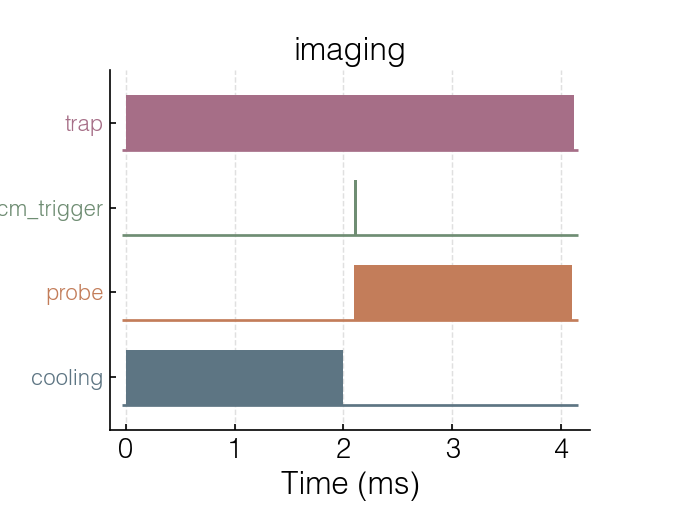

{'ok': True,
 'errors': [],
 'warnings': [],
 'sequence': [{'channel': 'cooling',
   'start': 0.0,
   'duration': 0.002,
   'value': 1,
   'name': 'load'},
  {'channel': 'trap',
   'start': 0.0,
   'duration': 0.0041199999999999995,
   'value': 1,
   'name': 'trap_hold'},
  {'channel': 'probe',
   'start': 0.0021,
   'duration': 0.002,
   'value': 1,
   'name': 'probe'},
  {'channel': 'qcm_trigger',
   'start': 0.0021,
   'duration': 2e-05,
   'value': 1,
   'name': 'camera_trigger'}],
 'devices': {'trap_array': {'type': 'VirtualTrapArray',
   'grid_shape': (5, 7),
   'image_shape': (96, 128),
   'offset_counts': 200.0,
   'conversion_e_per_count': 0.107,
   'read_noise_e': 0.43},
  'camera': {'type': 'VirtualCamera',
   'exposure': 0.002,
   'timeout': 2.0,
   'last_sequence': None},
  'sequencer': {'type': 'VirtualSequencer',
   'channels': ['trap',
    'cooling',
    'probe',
    'qcm_trigger',
    'camera_trigger',
    'trig',
    'pushout',
    'microwave'],
   'clock_hz': 2500000

In [5]:
exp.timing.configure_imaging(exposure=2e-3, load=True, trigger_width=20e-6, pre_trigger=100e-6)
pulse_plot = exp.timing.plot_sequence()
preflight = exp.timing.preflight()
preflight.summary()

## Capture a camera image

`capture` 是 camera device 的方法，所以调用是 `exp.camera.capture()`。它永远只显示 raw camera frame，不自动叠加 sitemap 圈；site overlay 只属于 calibration/readout/detect 图。virtual camera 参考 C15550-22UP 的量级：约 200 counts offset、0.107 electrons/count、0.43 electrons RMS readout noise。

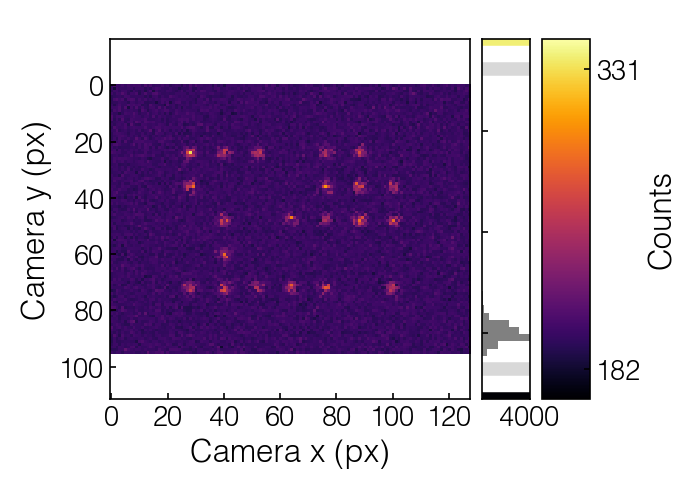

{'frames': 1, 'image_shape': [96, 128], 'sequence': 'imaging'}

In [6]:
capture = exp.camera.capture(display=True)
capture.summary()

## Calibrate sitemap

`sitemap` 只回答“每个 trap site 在 camera 上在哪里”。输出包含 `centers`、`calibration`、`average_image` 和 frontend plot handle。

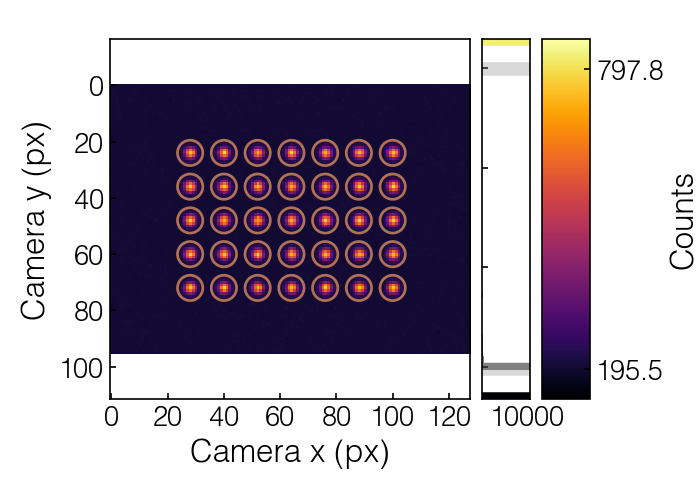

{'n_sites': 35, 'grid_shape': [5, 7], 'roi_radius': 1}

In [7]:
sitemap = exp.readout.sitemap(frames=12, display=True)
sitemap.summary()

## Calibrate thresholds

这个步骤依赖 sitemap。histogram 里的 threshold 线可拖动；右上角显示当前 threshold、左右比例、双峰 Gaussian fidelity 和模型交点 `fit cut`。

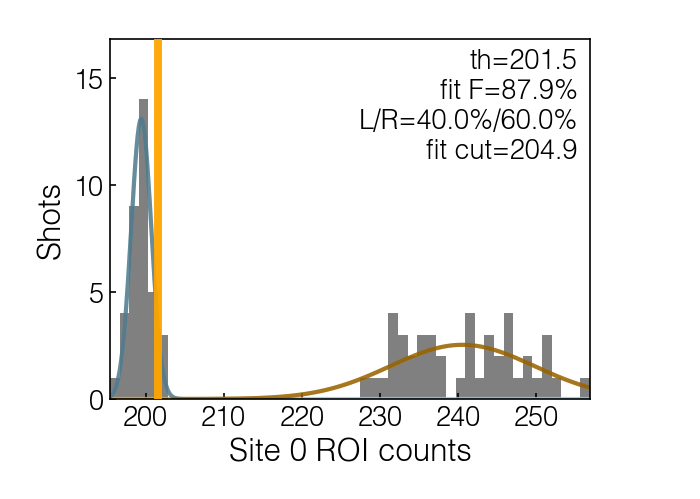

{'shots': 80,
 'sites': 35,
 'selected_site': 0,
 'selected_threshold': 201.52488425925927,
 'selected_fidelity': 0.6371414979899874}

In [8]:
threshold = exp.readout.thresholds(frames=80, site=0, display=True)
threshold.summary()

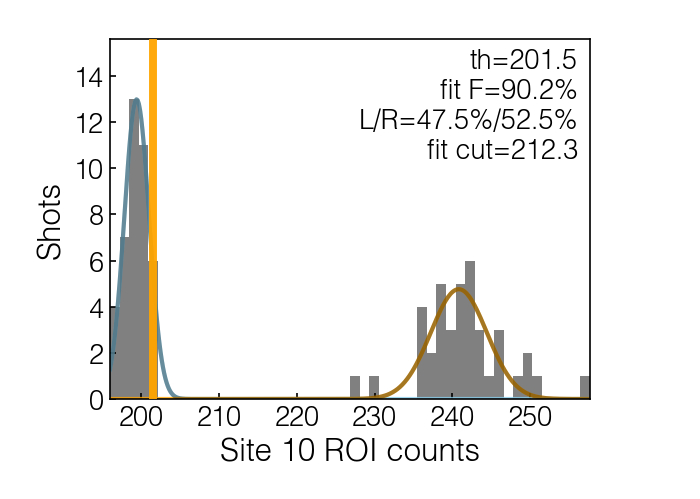

{'shots': 80,
 'sites': 35,
 'selected_site': 10,
 'selected_threshold': 201.46006944444446,
 'selected_fidelity': 0.7775495978602414}

In [9]:
threshold.plot_site(site=10, display=True)
threshold.summary()

## Detect one shot

detect 图显示 raw camera data：所有 sitemap site 有很浅的背景圆圈，只有判断为 occupied 的 site 画较细的橙色圆圈。`DetectionResult.occupied` 是后续 rearrangement 或 statistics 可以直接使用的 boolean array。

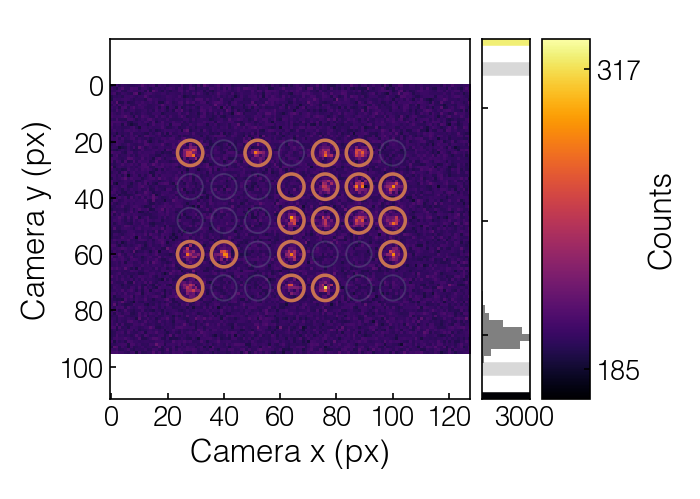

array([[ True, False,  True, False,  True,  True, False],
       [False, False, False,  True,  True,  True,  True],
       [False, False, False,  True,  True,  True,  True],
       [ True,  True, False,  True, False, False,  True],
       [ True, False, False,  True,  True, False, False]])

In [10]:
shot = exp.readout.detect(display=True)
occupancy_grid = shot.occupied.reshape(exp.devices.trap_array.grid_shape)
occupancy_grid

## Standalone array analysis

有些算法不应该绑死在 session 上。只给 images 和 calibration，也可以重算 sitemap、threshold 或 detect。

In [11]:
standalone_sequence = na.imaging_sequence(exposure=exp.camera.exposure, load=True, name="sitemap")
standalone_images = exp.camera.acquire(4, sequence=standalone_sequence)
standalone_sitemap = na.calibrate_sitemap_from_images(
    standalone_images,
    grid_shape=exp.devices.trap_array.grid_shape,
    display=False,
)
standalone_threshold = na.calibrate_threshold_from_images(
    exp.camera.capture(frames=12, display=False).images,
    standalone_sitemap.calibration,
    display=False,
)
standalone_shot = na.detect_image(capture.image, standalone_threshold.calibration, display=False)
standalone_shot.occupied.shape

(35,)

## Scan detection time and fidelity

`detection_time` 不使用 virtual ground truth。它先拍 long-exposure reference images，然后对每个 detection time 的 ROI count distribution 做 threshold 和 Gaussian split fidelity 估计。接口默认 `live=True`，但这里为了马上在同一个 `scan` 上做 fit，显式设成 `live=False`，让这个 cell 返回时数据已经采完。

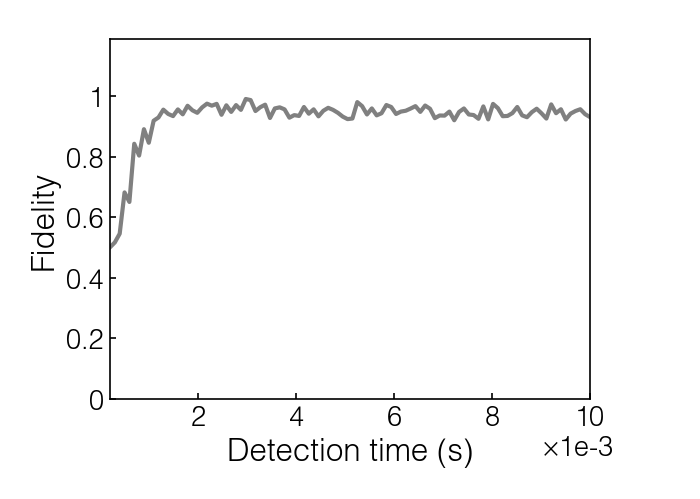

({'points': 100,
  'points_done': 100,
  'running': False,
  'finished': True,
  'best': {'time': 0.0029717171717171718, 'fidelity': 0.9911276663012465}},
 FitResult(names=['A', 'B', 'tau'], popt=array([-7.49923960e-01,  9.54675853e-01,  4.90000000e-04]), pcov=array([[1.70601946e-03, 1.32321262e-05, 1.03206844e-06],
        [1.32321262e-05, 7.57743488e-06, 2.72470917e-08],
        [1.03206844e-06, 2.72470917e-08, 8.88298403e-10]]), function='decay'),
 array([-7.49923960e-01,  9.54675853e-01,  4.90000000e-04]))

In [12]:
times = np.linspace(0.2e-3, 10e-3, 100)
scan = exp.readout.detection_time(times, shots=30, live=False, display=True)
fit_result, popt = scan.data_figure.decay()
scan.summary(), fit_result, popt

## Interrupt a long live scan

对 notebook 和未来 GUI 来说，外部只需要一个 stop：`scan.stop()`。它转发到 frontend `RunSession.stop()`，这个 session 会请求 acquisition worker/source 停止，并停止 attached plot refresh timer。已经采到的数据仍然留在 `scan.fidelities` 里，可以继续保存或做粗略诊断。

内部仍然保留 `scan.measurement`、`scan.plot`、`scan.data_figure` 这三个部件，方便 debug 或 GUI 接管；但普通实验流程不要把 stop 拆成两套 API。

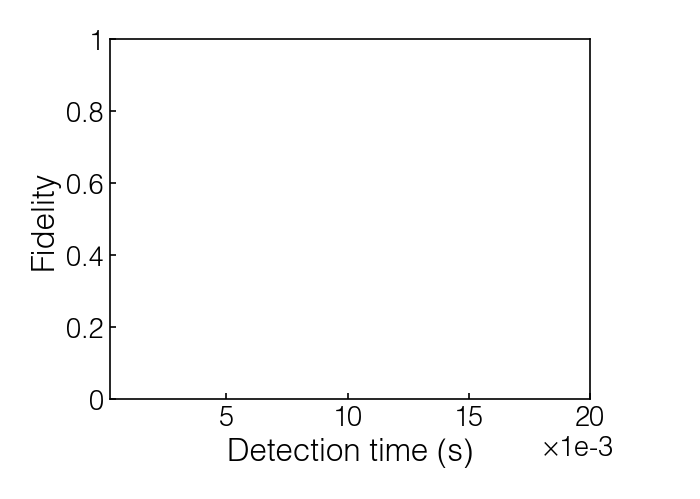

Live measurement started. Call scan.stop() to stop measurement and plot.


{'points': 200,
 'points_done': 0,
 'running': False,
 'finished': False,
 'best': None}

In [13]:
interrupt_scan = exp.readout.detection_time(np.linspace(0.2e-3, 20e-3, 200), shots=30, display=True)
interrupt_scan.stop()
interrupt_scan.summary()

## Save calibration, status, and Verilog

当前 Verilog 生成的是轻量 edge-table module。它已经足够检查 timing/channel/tick，但还不是完整 address_switch register/VIO 体系。

In [14]:
Path("results").mkdir(exist_ok=True)
Path("generated_sequences").mkdir(exist_ok=True)

calibration_path = exp.readout.save("results/neutral_atom_quickstart_calibration.json")
status_path = exp.save_status("results/neutral_atom_quickstart_status.json")
verilog_path = exp.timing.write_verilog("generated_sequences")

calibration_path, status_path, verilog_path

(WindowsPath('results/neutral_atom_quickstart_calibration.json'),
 WindowsPath('results/neutral_atom_quickstart_status.json'),
 WindowsPath('generated_sequences/neutral_atom_sequence.v'))